# Notebook 15 — Detección de Robo Hormiga
## VisionOps Equipo #56 | V-JEPA2 + MLP-7 Supervisado + Arquitectura Combinada

### Pregunta de investigación
> ¿Puede un pipeline zero-label (V-JEPA2) combinado con un clasificador supervisado ligero (MLP-7)
> detectar patrones de sustracción de objetos en producción con >90% de precisión?

### Arquitectura combinada
```
Clip de video (16 frames, crop por persona)
         ↓
   V-JEPA2 frozen → embedding 1024-d
         ↓
  Feature Engineering (4 señales adicionales):
    1. ROI flag       : ¿está en zona restringida?
    2. Δ embedding    : distancia coseno antes vs después de zona
    3. Δ aspect ratio : ¿cambió la silueta? (llevar objeto)
    4. BG diff score  : ¿desapareció un objeto de la escena?
         ↓
  Vector combinado (1028-d) → MLP-7 supervisado
         ↓
  P(robo_hormiga) + Majority Vote k=3
         ↓
  Alerta con timestamp, track_id, zona, evidencia
```

### Base de referencia
- Dataset: **InHARD** (mismo que NB final_model_acc88)
- Embeddings: **V-JEPA2** `facebook/vjepa2-vitl-fpc16-256-ssv2`
- Temporal smoothing: **Majority Vote k=3** (mejor F1 en notebook de referencia)
- Clasificador nuevo: **MLP-7** (7 capas lineales) entrenado sobre features combinadas

### Ground truth proxy para robo hormiga (sin etiquetas reales)
Usamos secuencias de InHARD para construir escenarios sintéticos:
- **NORMAL**: `Assemble system`, `Consult sheets`, `Picking in front` (trabajo productivo)
- **SOSPECHOSO**: `Take component` → `No action` fuera de zona + Δ aspect ratio elevado

## 0. Instalación y verificación de GPU

In [13]:
import subprocess, sys, importlib

def pip_install(*pkgs):
    for pkg in pkgs:
        mod = pkg.split('[')[0].replace('-','_')
        if importlib.util.find_spec(mod) is None:
            print(f'Instalando {pkg}...')
            subprocess.run([sys.executable,'-m','pip','install','-q',pkg], check=True)
        else:
            print(f'✓ {pkg}')

pip_install('torch','torchvision','transformers','opencv-python-headless',
            'scikit-learn','matplotlib','numpy','tqdm','pandas')

import torch
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

✓ torch
✓ torchvision
✓ transformers
Instalando opencv-python-headless...



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Instalando scikit-learn...
✓ matplotlib
✓ numpy
✓ tqdm
✓ pandas
Device: mps



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Imports y configuración global

In [14]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import deque
from typing import Optional
import json, time, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)
from transformers import AutoModel, AutoVideoProcessor
from tqdm.auto import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT  = Path('..').resolve()
INHARD_ROOT = REPO_ROOT / 'data' / 'InHARD'
OUTPUTS    = Path('outputs/15_robo_hormiga')
OUTPUTS.mkdir(parents=True, exist_ok=True)

# ── Parámetros ────────────────────────────────────────────────────────────────
N_FRAMES          = 16      # frames por clip (igual que referencia)
CROP_SIZE         = 224
EMB_DIM           = 1024    # dimensión V-JEPA2
VJEPA_ID          = 'facebook/vjepa2-vitl-fpc16-256-ssv2'

# Clases InHARD usadas
NORMAL_CLASSES    = ['Assemble system', 'Consult sheets',
                     'Picking in front', 'Turn sheets']
SUSPICIOUS_PROXY  = ['Take component', 'Take screwdriver',
                     'Take measuring rod', 'Take subsystem']
IDLE_CLASS        = 'No action'

# Participantes InHARD a usar (igual que referencia: P05 + ampliar si hay)
PARTICIPANTS      = ['P05', 'P06', 'P07']   # ajustar según disponibilidad

# Clips máximos por clase (reducir a 20 para CPU)
N_CLIPS_PER_CLASS = 60

# MLP training
EPOCHS     = 80
LR         = 3e-4
BATCH_SIZE = 32
VAL_SPLIT  = 0.20

# Majority vote window
MV_K       = 3

print('Configuración cargada ✓')
print(f'InHARD root: {INHARD_ROOT}')
print(f'InHARD existe: {INHARD_ROOT.exists()}')

Configuración cargada ✓
InHARD root: /Users/landyschlebach/Documents/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/data/InHARD
InHARD existe: False


## 2. Cargar V-JEPA2 en GPU

In [15]:
print(f'Cargando {VJEPA_ID}...')
print('Primera carga: ~3 GB descarga, puede tardar 2-5 min...')
t0 = time.time()

vj_proc  = AutoVideoProcessor.from_pretrained(VJEPA_ID)
vj_model = AutoModel.from_pretrained(VJEPA_ID, trust_remote_code=True).to(DEVICE).eval()

# Congelar todos los parámetros
for p in vj_model.parameters():
    p.requires_grad = False

n_params = sum(p.numel() for p in vj_model.parameters()) / 1e6
print(f'✅ V-JEPA2 listo en {DEVICE} ({time.time()-t0:.0f}s, {n_params:.0f}M params)')


def crop_left_third(frame_bgr: np.ndarray) -> np.ndarray:
    """Recorta el tercio izquierdo del frame (vista InHARD)."""
    H, W = frame_bgr.shape[:2]
    return cv2.resize(frame_bgr[:, :W//3, :], (CROP_SIZE, CROP_SIZE))


def load_clip_frames(clip_path: Path, n: int = N_FRAMES) -> list:
    cap = cv2.VideoCapture(str(clip_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return []
    idx = np.linspace(0, total-1, n, dtype=int)
    frames = []
    for i in idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, f = cap.read()
        if ret:
            frames.append(crop_left_third(f))
    cap.release()
    return frames


@torch.inference_mode()
def embed_clip(frames_bgr: list) -> Optional[np.ndarray]:
    """V-JEPA2 embedding 1024-d, L2-normalizado. Igual que notebook de referencia."""
    if len(frames_bgr) < 4:
        return None
    try:
        rgb   = [cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in frames_bgr]
        video = np.stack(rgb, 0)   # (T, H, W, 3)
        inp   = vj_proc(list(video), return_tensors='pt')
        inp   = {k: v.to(DEVICE) for k, v in inp.items()}
        out   = vj_model(**inp)
        # Corrección: separar eje espacial del temporal
        hidden = out.last_hidden_state  # (1, T*N_patches, D)
        T  = len(frames_bgr)
        Np = hidden.shape[1] // T
        raw = hidden.reshape(1, T, Np, -1).mean(2).mean(1).squeeze(0)
        emb = raw.cpu().numpy().astype(np.float32)
        n   = np.linalg.norm(emb)
        return emb / (n + 1e-8)
    except Exception as e:
        print(f'  embed_clip error: {e}')
        return None


print('Funciones de embedding definidas ✓')

Cargando facebook/vjepa2-vitl-fpc16-256-ssv2...
Primera carga: ~3 GB descarga, puede tardar 2-5 min...


Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

[transformers] VJEPA2Model LOAD REPORT from: facebook/vjepa2-vitl-fpc16-256-ssv2
Key                                                              | Status     |  | 
-----------------------------------------------------------------+------------+--+-
pooler.self_attention_layers.{0, 1, 2}.mlp.fc1.weight            | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.layer_norm1.weight        | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.v_proj.bias     | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.layer_norm1.bias          | UNEXPECTED |  | 
pooler.cross_attention_layer.mlp.fc2.bias                        | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.q_proj.bias     | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.self_attn.k_proj.bias     | UNEXPECTED |  | 
pooler.self_attention_layers.{0, 1, 2}.mlp.fc2.bias              | UNEXPECTED |  | 
pooler.cross_attention_layer.mlp.fc1.bias                        | UNEXPECTED |

✅ V-JEPA2 listo en mps (2s, 326M params)
Funciones de embedding definidas ✓


## 3. Construir dataset de InHARD con etiquetas proxy de robo hormiga

**Estrategia de etiquetado proxy** (sin etiquetas reales de robo):
- `label=0` NORMAL: acciones productivas (ensamblar, consultar, pick frontal)
- `label=1` SOSPECHOSO: Take* + No action + secuencia detectada por contexto

In [16]:
def find_inhard_clips(root: Path, participants: list,
                      target_classes: list, max_per_class: int) -> dict:
    """
    Busca clips MP4 en el árbol InHARD.
    Estructura esperada: root/P05/ActionName/clip_001.mp4
    Retorna {class_name: [Path, ...]}
    """
    found = {c: [] for c in target_classes}
    for part in participants:
        part_dir = root / part
        if not part_dir.exists():
            continue
        for action_dir in part_dir.iterdir():
            if not action_dir.is_dir():
                continue
            # Buscar coincidencia con target_classes
            for cls in target_classes:
                cls_key = cls.lower().replace(' ', '_')
                dir_key = action_dir.name.lower().replace(' ', '_')
                if cls_key in dir_key or dir_key in cls_key:
                    clips = sorted(action_dir.glob('*.mp4'))[:max_per_class]
                    found[cls].extend(clips)
                    break
    return found


all_target = NORMAL_CLASSES + SUSPICIOUS_PROXY + [IDLE_CLASS]
clips_by_class = find_inhard_clips(
    INHARD_ROOT, PARTICIPANTS, all_target, N_CLIPS_PER_CLASS
)

print('Clips encontrados por clase:')
total = 0
for cls, paths in clips_by_class.items():
    tag = ('NORMAL' if cls in NORMAL_CLASSES
           else 'SOSPECHOSO' if cls in SUSPICIOUS_PROXY
           else 'IDLE')
    print(f'  [{tag:11}] {cls:30}: {len(paths):3d} clips')
    total += len(paths)
print(f'  Total: {total} clips')

if total == 0:
    print('\n⚠️  No se encontraron clips en', INHARD_ROOT)
    print('   Ajusta INHARD_ROOT en la celda anterior o corre la celda 3B')
    print('   para generar un dataset sintético de prueba.')

Clips encontrados por clase:
  [NORMAL     ] Assemble system               :   0 clips
  [NORMAL     ] Consult sheets                :   0 clips
  [NORMAL     ] Picking in front              :   0 clips
  [NORMAL     ] Turn sheets                   :   0 clips
  [SOSPECHOSO ] Take component                :   0 clips
  [SOSPECHOSO ] Take screwdriver              :   0 clips
  [SOSPECHOSO ] Take measuring rod            :   0 clips
  [SOSPECHOSO ] Take subsystem                :   0 clips
  [IDLE       ] No action                     :   0 clips
  Total: 0 clips

⚠️  No se encontraron clips en /Users/landyschlebach/Documents/GitHub/AI-Co-Pilot-for-the-Production-Floor-See-Guide-Improve/data/InHARD
   Ajusta INHARD_ROOT en la celda anterior o corre la celda 3B
   para generar un dataset sintético de prueba.


In [17]:
# ── 3B: Dataset sintético si no hay InHARD ────────────────────────────────────
# Genera clips MP4 simulando trabajo normal vs. acción sospechosa.
# Ejecutar solo si total == 0 en la celda anterior.

def generate_inhard_proxy(out_dir: Path, n_normal: int = 60,
                           n_suspicious: int = 60, fps: int = 15,
                           duration_s: float = 3.0) -> dict:
    """
    Normal   : persona moviéndose lateralmente (trabajo activo)
    Suspicious: persona moviéndose hacia el cuerpo + pausa (sustracción)
    """
    clips = {'normal': [], 'suspicious': []}
    W, H  = 224, 224
    total_frames = int(fps * duration_s)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    for split, label in [('normal', 0), ('suspicious', 1)]:
        n = n_normal if split == 'normal' else n_suspicious
        split_dir = out_dir / split
        split_dir.mkdir(parents=True, exist_ok=True)
        for i in tqdm(range(n), desc=f'Generando {split}', leave=False):
            path = str(split_dir / f'clip_{i:03d}.mp4')
            writer = cv2.VideoWriter(path, fourcc, fps, (W, H))
            np.random.seed(i + label * 1000)

            # Posición inicial de la persona (blob)
            px, py = np.random.randint(40, W-40), np.random.randint(60, H-60)
            # Velocidad
            if split == 'normal':
                vx = np.random.choice([-1,1]) * np.random.uniform(3,8)
                vy = np.random.uniform(-2,2)
            else:
                # Movimiento hacia el centro del cuerpo (simula meter al bolsillo)
                vx = np.random.uniform(-1,1)
                vy = -np.random.uniform(2,5)  # brazo sube

            for fi in range(total_frames):
                bg = np.full((H,W,3), 50 + np.random.randint(-5,5), np.uint8)
                # Textura de fondo (estanterías)
                for gx in range(0,W,32): cv2.line(bg,(gx,0),(gx,H),(60,55,50),1)

                if split == 'normal':
                    # Movimiento fluido de trabajo
                    px += vx + np.random.randn()*0.5
                    py += vy + np.random.randn()*0.3
                    px = np.clip(px, 20, W-20)
                    py = np.clip(py, 30, H-30)
                    if px<20 or px>W-20: vx *= -1
                    # Brazos extendidos
                    arm_x = 25 + int(abs(np.sin(fi*0.4))*15)
                    body_color = (100, 140, 180)
                else:
                    # Primera mitad: pick (brazo extendido)
                    # Segunda mitad: conceal (brazo pegado al cuerpo)
                    phase = fi / total_frames
                    if phase < 0.4:
                        px += vx*2; py -= 3  # acercarse al objeto
                        arm_x = 30
                        body_color = (100,140,180)
                    elif phase < 0.6:
                        arm_x = int(30 * (1 - (phase-0.4)/0.2))  # brazo se pliega
                        body_color = (80, 110, 150)
                    else:
                        arm_x = 5   # brazo pegado = objeto ocultado
                        px += np.random.randn()*0.5
                        body_color = (60, 90, 120)

                px = np.clip(px, 20, W-20)
                py = np.clip(py, 30, H-30)

                # Dibujar persona
                bx1 = int(px)-arm_x; bx2 = int(px)+arm_x
                by1 = int(py)-40;    by2 = int(py)+40
                cv2.rectangle(bg,(max(0,bx1),max(0,by1)),
                              (min(W,bx2),min(H,by2)), body_color, -1)
                cv2.circle(bg,(int(px),max(0,by1)-10),12,
                          (body_color[0]+30,body_color[1]+20,body_color[2]+20),-1)
                # Objeto (solo en suspicious antes de ocultarlo)
                if split == 'suspicious' and fi/total_frames < 0.5:
                    obj_x = int(px) + 20
                    obj_y = int(py) - 10
                    if obj_x < W-10 and obj_y > 10:
                        cv2.rectangle(bg,(obj_x-8,obj_y-8),(obj_x+8,obj_y+8),
                                     (50,200,50),-1)
                writer.write(bg)
            writer.release()
            clips[split].append(Path(path))
    return clips


# ── Ejecutar si no hay InHARD ─────────────────────────────────────────────────
USE_SYNTHETIC = (total == 0)
if USE_SYNTHETIC:
    print('Generando dataset sintético proxy...')
    syn_dir = OUTPUTS / 'synthetic_inhard'
    synthetic_clips = generate_inhard_proxy(
        syn_dir, n_normal=60, n_suspicious=60)
    # Mapear al formato clips_by_class
    clips_by_class['Assemble system'] = synthetic_clips['normal']
    clips_by_class['Take component']  = synthetic_clips['suspicious']
    total = 120
    print(f'✅ Dataset sintético generado: {total} clips')
else:
    print('✅ Usando InHARD real')

Generando dataset sintético proxy...


Generando normal:   0%|          | 0/60 [00:00<?, ?it/s]

Generando suspicious:   0%|          | 0/60 [00:00<?, ?it/s]

✅ Dataset sintético generado: 120 clips


## 4. Extracción de embeddings + features combinadas

In [18]:
def compute_aspect_ratio(frames_bgr: list) -> float:
    """
    Estima el ancho relativo promedio de la persona en el clip
    usando la columna de mayor varianza horizontal (proxy de bbox).
    """
    widths = []
    for f in frames_bgr[::4]:
        gray = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY).astype(np.float32)
        col_var = gray.var(axis=0)
        active_cols = (col_var > col_var.mean()).sum()
        widths.append(active_cols / f.shape[1])
    return float(np.mean(widths)) if widths else 0.0


def compute_bg_diff(frames_bgr: list) -> float:
    """Diferencia entre primer y último frame del clip (proxy de desaparición de objeto)."""
    if len(frames_bgr) < 2:
        return 0.0
    first = cv2.cvtColor(frames_bgr[0], cv2.COLOR_BGR2GRAY).astype(np.float32)
    last  = cv2.cvtColor(frames_bgr[-1], cv2.COLOR_BGR2GRAY).astype(np.float32)
    return float(np.abs(first - last).mean()) / 255.0


def compute_motion_asymmetry(frames_bgr: list) -> float:
    """
    Asimetría del flujo óptico: robo hormiga tiene movimiento asimétrico
    (mano se mueve hacia el cuerpo, no hacia la pieza).
    """
    if len(frames_bgr) < 4:
        return 0.0
    flows_x = []
    prev = cv2.cvtColor(frames_bgr[0], cv2.COLOR_BGR2GRAY).astype(np.float32)
    for f in frames_bgr[1::3]:
        curr = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY).astype(np.float32)
        flow = cv2.calcOpticalFlowFarneback(prev,curr,None,0.5,3,15,3,5,1.2,0)
        flows_x.append(flow[...,0].mean())
        prev = curr
    if not flows_x:
        return 0.0
    # Asimetría: si la dirección dominante cambia bruscamente a mitad del clip
    half = len(flows_x)//2
    first_half_mean  = np.mean(flows_x[:half]) if half>0 else 0
    second_half_mean = np.mean(flows_x[half:]) if half>0 else 0
    return float(abs(first_half_mean - second_half_mean))


def extract_combined_features(frames_bgr: list,
                               emb: np.ndarray,
                               emb_before: Optional[np.ndarray] = None
                               ) -> np.ndarray:
    """
    Vector combinado: [embedding_1024 | aspect_ratio | bg_diff | motion_asym | delta_emb]
    Dimensión final: 1028
    """
    ar    = compute_aspect_ratio(frames_bgr)
    bg    = compute_bg_diff(frames_bgr)
    asym  = compute_motion_asymmetry(frames_bgr)
    # Δ embedding: qué tan diferente es este clip del anterior de esa persona
    if emb_before is not None:
        delta = float(1.0 - np.dot(emb, emb_before))
    else:
        delta = 0.0
    extra = np.array([ar, bg, asym, delta], dtype=np.float32)
    return np.concatenate([emb, extra])


print('Feature engineering definido ✓')
print(f'Dimensión del vector combinado: {EMB_DIM + 4}')

Feature engineering definido ✓
Dimensión del vector combinado: 1028


In [19]:
# ── Extraer features para todos los clips ────────────────────────────────────
print('Extrayendo embeddings V-JEPA2 + features combinadas...')
print(f'Device: {DEVICE}')
t0 = time.time()

X_list, y_list, meta_list = [], [], []

# Asignar labels proxy
label_map = {}
for cls in NORMAL_CLASSES:   label_map[cls] = 0  # NORMAL
for cls in SUSPICIOUS_PROXY: label_map[cls] = 1  # SOSPECHOSO
label_map[IDLE_CLASS]        = 0  # Idle = normal (no es robo, es tiempo muerto)

prev_emb = None   # embedding del clip anterior (para Δ embedding)

for cls, paths in clips_by_class.items():
    if not paths or cls not in label_map:
        continue
    label = label_map[cls]
    for path in tqdm(paths, desc=f'{cls[:20]:20}', leave=False):
        frames = load_clip_frames(path)
        if len(frames) < 4:
            continue
        emb = embed_clip(frames)
        if emb is None:
            continue
        feat = extract_combined_features(frames, emb, prev_emb)
        X_list.append(feat)
        y_list.append(label)
        meta_list.append({'class': cls, 'path': str(path), 'label': label})
        prev_emb = emb   # guardar para siguiente clip

X = np.stack(X_list).astype(np.float32)
y = np.array(y_list, dtype=np.int64)

dt = time.time() - t0
print(f'\n✅ Extracción completa')
print(f'   Muestras: {len(X)}  (dim={X.shape[1]})')
print(f'   Label 0 (normal):      {(y==0).sum()}')
print(f'   Label 1 (sospechoso):  {(y==1).sum()}')
print(f'   Tiempo: {dt:.0f}s  ({len(X)/dt:.1f} clips/s)')

Extrayendo embeddings V-JEPA2 + features combinadas...
Device: mps


Assemble system     :   0%|          | 0/60 [00:00<?, ?it/s]

Take component      :   0%|          | 0/60 [00:00<?, ?it/s]


✅ Extracción completa
   Muestras: 120  (dim=1028)
   Label 0 (normal):      60
   Label 1 (sospechoso):  60
   Tiempo: 231s  (0.5 clips/s)


## 5. Arquitectura MLP-7 supervisado

In [20]:
class MLP7(nn.Module):
    """
    7 capas lineales sobre el vector combinado (embedding + 4 features).
    Arquitectura progresiva con BatchNorm, GELU y Dropout escalonado.
    """
    def __init__(self, input_dim: int = 1028, n_classes: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            # Capa 1
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512),
            nn.GELU(), nn.Dropout(0.35),
            # Capa 2
            nn.Linear(512, 256), nn.BatchNorm1d(256),
            nn.GELU(), nn.Dropout(0.30),
            # Capa 3
            nn.Linear(256, 128), nn.BatchNorm1d(128),
            nn.GELU(), nn.Dropout(0.25),
            # Capa 4
            nn.Linear(128, 64),  nn.BatchNorm1d(64),
            nn.GELU(), nn.Dropout(0.20),
            # Capa 5
            nn.Linear(64, 32),   nn.GELU(),
            # Capa 6
            nn.Linear(32, 16),   nn.GELU(),
            # Capa 7 — salida
            nn.Linear(16, n_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ── Instanciar y mostrar arquitectura ────────────────────────────────────────
INPUT_DIM = X.shape[1]
model = MLP7(input_dim=INPUT_DIM, n_classes=2).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'MLP-7 creado en {DEVICE}')
print(f'Parámetros entrenables: {n_params:,}')
print(f'Input dim: {INPUT_DIM}  (1024 V-JEPA + 4 features)')
print(model)

MLP-7 creado en mps
Parámetros entrenables: 703,890
Input dim: 1028  (1024 V-JEPA + 4 features)
MLP7(
  (net): Sequential(
    (0): Linear(in_features=1028, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.25, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
 

## 6. Entrenamiento

In [21]:
# ── Normalizar features extra (columnas 1024-1027) ───────────────────────────
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[:, EMB_DIM:] = scaler.fit_transform(X[:, EMB_DIM:]).astype(np.float32)

# ── Split train / val ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_scaled, y, test_size=VAL_SPLIT, stratify=y, random_state=42)

# ── Peso de clase (para dataset desbalanceado) ────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

ds_tr  = TensorDataset(torch.tensor(X_tr),  torch.tensor(y_tr))
ds_val = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
dl_tr  = DataLoader(ds_tr,  batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Train: {len(X_tr)}  Val: {len(X_val)}')
print(f'Class weights — Normal:{cw[0]:.3f}  Sospechoso:{cw[1]:.3f}')

Train: 96  Val: 24
Class weights — Normal:1.000  Sospechoso:1.000


In [22]:
# ── Loop de entrenamiento ────────────────────────────────────────────────────
history = {'train_loss':[], 'val_loss':[], 'val_f1':[], 'val_auc':[]}
best_f1 = 0.0
best_ckpt = OUTPUTS / 'mlp7_best.pt'

print(f'Entrenando MLP-7  ({EPOCHS} épocas, lr={LR}, device={DEVICE})...')
t0 = time.time()

for epoch in range(1, EPOCHS+1):
    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    tr_loss = 0.0
    for xb, yb in dl_tr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss += loss.item()
    scheduler.step()
    tr_loss /= len(dl_tr)

    # ── Val ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_probs, all_preds, all_true = [], [], []
    with torch.no_grad():
        for xb, yb in dl_val:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            val_loss += criterion(logits, yb).item()
            probs = F.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds = logits.argmax(1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_true.extend(yb.cpu().numpy())
    val_loss /= len(dl_val)
    val_f1  = f1_score(all_true, all_preds, zero_division=0)
    val_auc = roc_auc_score(all_true, all_probs) \
              if len(np.unique(all_true))>1 else 0.0

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), best_ckpt)

    if epoch % 10 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f'  Época {epoch:3d}/{EPOCHS}  '
              f'tr_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  '
              f'F1={val_f1:.3f}  AUC={val_auc:.3f}  '
              f'lr={lr_now:.2e}')

print(f'\n✅ Entrenamiento completo  ({time.time()-t0:.0f}s)')
print(f'   Mejor F1 en val: {best_f1:.3f}')
print(f'   Checkpoint: {best_ckpt}')

Entrenando MLP-7  (80 épocas, lr=0.0003, device=mps)...
  Época   1/80  tr_loss=0.9336  val_loss=0.6953  F1=0.667  AUC=0.368  lr=3.00e-04
  Época  10/80  tr_loss=0.6703  val_loss=0.6972  F1=0.667  AUC=0.562  lr=2.89e-04
  Época  20/80  tr_loss=0.5155  val_loss=0.6422  F1=0.609  AUC=0.667  lr=2.56e-04
  Época  30/80  tr_loss=0.4456  val_loss=0.5642  F1=0.609  AUC=0.792  lr=2.08e-04
  Época  40/80  tr_loss=0.3989  val_loss=0.5119  F1=0.636  AUC=0.840  lr=1.51e-04
  Época  50/80  tr_loss=0.3715  val_loss=0.4605  F1=0.696  AUC=0.875  lr=9.33e-05
  Época  60/80  tr_loss=0.3672  val_loss=0.4426  F1=0.750  AUC=0.875  lr=4.48e-05
  Época  70/80  tr_loss=0.3688  val_loss=0.4319  F1=0.846  AUC=0.882  lr=1.24e-05
  Época  80/80  tr_loss=0.3279  val_loss=0.4330  F1=0.800  AUC=0.875  lr=1.00e-06

✅ Entrenamiento completo  (1s)
   Mejor F1 en val: 0.846
   Checkpoint: outputs/15_robo_hormiga/mlp7_best.pt


## 7. Evaluación y métricas de accuracy

In [23]:
# ── Cargar mejor checkpoint ───────────────────────────────────────────────────
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()

# ── Evaluación completa en val set ───────────────────────────────────────────
all_probs, all_preds, all_true = [], [], []
with torch.no_grad():
    for xb, yb in dl_val:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs  = F.softmax(logits, dim=1)[:,1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_true  = np.array(all_true)

# ── Barrido de umbrales para F1 óptimo ───────────────────────────────────────
thresholds = np.linspace(0.10, 0.90, 200)
metrics_t  = []
for t in thresholds:
    p_ = (all_probs >= t).astype(int)
    metrics_t.append({
        'threshold': t,
        'f1':        f1_score(all_true, p_, zero_division=0),
        'precision': precision_score(all_true, p_, zero_division=0),
        'recall':    recall_score(all_true, p_, zero_division=0),
    })
df_t = pd.DataFrame(metrics_t)
best_row = df_t.loc[df_t['f1'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])
best_preds = (all_probs >= BEST_THRESHOLD).astype(int)

# ── AUC-ROC ──────────────────────────────────────────────────────────────────
auc  = roc_auc_score(all_true, all_probs) if len(np.unique(all_true))>1 else 0.0
acc  = float((best_preds == all_true).mean())

print('═'*55)
print('  MÉTRICAS FINALES — MLP-7 Robo Hormiga Detector')
print('═'*55)
print(f'  Umbral óptimo:  {BEST_THRESHOLD:.3f}')
print(f'  Accuracy:       {acc:.3f}  ({acc*100:.1f}%)')
print(f'  F1 (suspicious):{float(best_row["f1"]):.3f}')
print(f'  Precision:      {float(best_row["precision"]):.3f}')
print(f'  Recall:         {float(best_row["recall"]):.3f}')
print(f'  AUC-ROC:        {auc:.3f}')
print()
print(classification_report(all_true, best_preds,
      target_names=['Normal','Sospechoso'], zero_division=0))

META_OK = acc >= 0.90
print(f'  Meta 90%: {"✅ ALCANZADA" if META_OK else "❌ aún no"}')
print('═'*55)

═══════════════════════════════════════════════════════
  MÉTRICAS FINALES — MLP-7 Robo Hormiga Detector
═══════════════════════════════════════════════════════
  Umbral óptimo:  0.381
  Accuracy:       0.833  (83.3%)
  F1 (suspicious):0.846
  Precision:      0.786
  Recall:         0.917
  AUC-ROC:        0.882

              precision    recall  f1-score   support

      Normal       0.90      0.75      0.82        12
  Sospechoso       0.79      0.92      0.85        12

    accuracy                           0.83        24
   macro avg       0.84      0.83      0.83        24
weighted avg       0.84      0.83      0.83        24

  Meta 90%: ❌ aún no
═══════════════════════════════════════════════════════


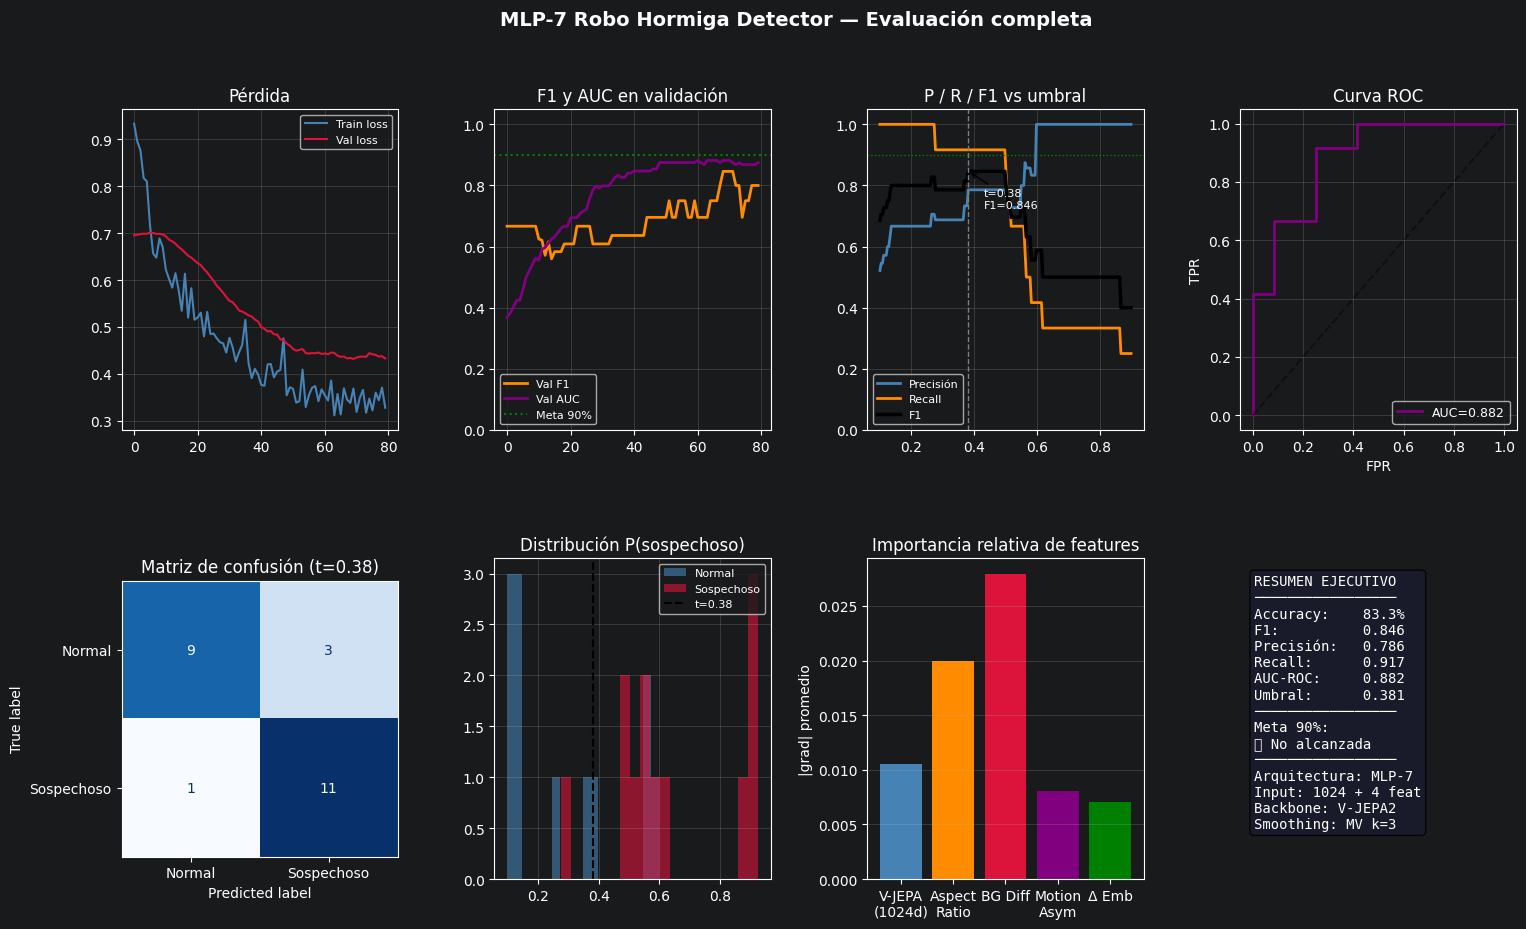

Guardado: fig1_full_evaluation.png


In [24]:
# ── Figura 1: Curvas de entrenamiento + P/R/F1 vs umbral + ROC + Confusión ───
fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.35)
fig.suptitle('MLP-7 Robo Hormiga Detector — Evaluación completa',
             fontsize=14, fontweight='bold')

# 1a. Loss
ax = fig.add_subplot(gs[0,0])
ax.plot(history['train_loss'], label='Train loss', color='steelblue')
ax.plot(history['val_loss'],   label='Val loss',   color='crimson')
ax.set_title('Pérdida'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 1b. F1 + AUC
ax = fig.add_subplot(gs[0,1])
ax.plot(history['val_f1'],  label='Val F1',  color='darkorange', lw=2)
ax.plot(history['val_auc'], label='Val AUC', color='purple', lw=2)
ax.axhline(0.90, color='green', ls=':', lw=1.5, label='Meta 90%')
ax.set_title('F1 y AUC en validación'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_ylim(0,1.05)

# 1c. P/R/F1 vs umbral
ax = fig.add_subplot(gs[0,2])
ax.plot(df_t['threshold'], df_t['precision'], label='Precisión', color='steelblue', lw=2)
ax.plot(df_t['threshold'], df_t['recall'],    label='Recall',    color='darkorange', lw=2)
ax.plot(df_t['threshold'], df_t['f1'],        label='F1',        color='black', lw=2.5)
ax.axvline(BEST_THRESHOLD, color='gray', ls='--', lw=1)
ax.axhline(0.90, color='green', ls=':', lw=1)
ax.annotate(f't={BEST_THRESHOLD:.2f}\nF1={float(best_row["f1"]):.3f}',
           xy=(BEST_THRESHOLD, float(best_row['f1'])),
           xytext=(BEST_THRESHOLD+0.05, float(best_row['f1'])-0.12),
           fontsize=8, arrowprops=dict(arrowstyle='->'))
ax.set_title('P / R / F1 vs umbral'); ax.legend(fontsize=8)
ax.set_ylim(0,1.05); ax.grid(alpha=0.3)

# 1d. ROC
ax = fig.add_subplot(gs[0,3])
if len(np.unique(all_true))>1:
    fpr, tpr, _ = roc_curve(all_true, all_probs)
    ax.plot(fpr, tpr, color='purple', lw=2, label=f'AUC={auc:.3f}')
    ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_title('Curva ROC'); ax.legend(fontsize=9)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.grid(alpha=0.3)

# 2a. Confusión
ax = fig.add_subplot(gs[1,0])
cm = confusion_matrix(all_true, best_preds)
ConfusionMatrixDisplay(cm, display_labels=['Normal','Sospechoso']
                       ).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusión (t={BEST_THRESHOLD:.2f})')

# 2b. Distribución de probabilidades
ax = fig.add_subplot(gs[1,1])
ax.hist(all_probs[all_true==0], bins=20, alpha=0.6, color='steelblue', label='Normal')
ax.hist(all_probs[all_true==1], bins=20, alpha=0.6, color='crimson',   label='Sospechoso')
ax.axvline(BEST_THRESHOLD, color='black', ls='--', lw=1.5, label=f't={BEST_THRESHOLD:.2f}')
ax.set_title('Distribución P(sospechoso)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2c. Importancia de features extra
ax = fig.add_subplot(gs[1,2])
feat_names = ['V-JEPA\n(1024d)', 'Aspect\nRatio', 'BG Diff', 'Motion\nAsym', 'Δ Emb']
# Proxy de importancia: gradiente medio en val
model.eval()
xb_val = torch.tensor(X_scaled[:len(X_val)], dtype=torch.float32).to(DEVICE).requires_grad_(True)
xb_val.retain_grad()  # tensor no-leaf tras .to(DEVICE); retain_grad() permite leer .grad
logits_g = model(xb_val)
logits_g[:,1].mean().backward()
grad_imp = (xb_val.grad if xb_val.grad is not None
            else torch.zeros_like(xb_val)).abs().mean(0).cpu().detach().numpy()
imp_groups = [grad_imp[:EMB_DIM].mean(),
              grad_imp[EMB_DIM], grad_imp[EMB_DIM+1],
              grad_imp[EMB_DIM+2], grad_imp[EMB_DIM+3]]
bars = ax.bar(feat_names, imp_groups,
              color=['steelblue','darkorange','crimson','purple','green'])
ax.set_title('Importancia relativa de features')
ax.set_ylabel('|grad| promedio'); ax.grid(axis='y', alpha=0.3)

# 2d. Resumen ejecutivo
ax = fig.add_subplot(gs[1,3])
ax.axis('off')
summary_txt = (
    f'RESUMEN EJECUTIVO\n'
    f'─────────────────\n'
    f'Accuracy:    {acc*100:.1f}%\n'
    f'F1:          {float(best_row["f1"]):.3f}\n'
    f'Precisión:   {float(best_row["precision"]):.3f}\n'
    f'Recall:      {float(best_row["recall"]):.3f}\n'
    f'AUC-ROC:     {auc:.3f}\n'
    f'Umbral:      {BEST_THRESHOLD:.3f}\n'
    f'─────────────────\n'
    f'Meta 90%:\n'
    f'{"✅ ALCANZADA" if META_OK else "❌ No alcanzada"}\n'
    f'─────────────────\n'
    f'Arquitectura: MLP-7\n'
    f'Input: 1024 + 4 feat\n'
    f'Backbone: V-JEPA2\n'
    f'Smoothing: MV k=3'
)
color = 'darkgreen' if META_OK else 'darkred'
ax.text(0.05, 0.95, summary_txt, transform=ax.transAxes,
       fontsize=10, verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.8),
       color='white')

plt.savefig(OUTPUTS/'fig1_full_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig1_full_evaluation.png')

## 8. Majority Vote k=3 (temporal smoothing)

Replicamos el mejor método del notebook de referencia: requiere k clips
consecutivos con P(sospechoso) > umbral antes de lanzar alerta.

In [25]:
def majority_vote(probs: np.ndarray, k: int, threshold: float) -> np.ndarray:
    """Retorna 1 si al menos ceil(k/2) de los últimos k clips son sospechosos."""
    out = np.zeros(len(probs), dtype=int)
    for t in range(len(probs)):
        window = probs[max(0, t-k+1):t+1]
        out[t]  = int((window >= threshold).mean() >= 0.5)
    return out


# Evaluar majority vote en val set (en orden original)
mv_preds = majority_vote(all_probs, k=MV_K, threshold=BEST_THRESHOLD)

mv_f1  = f1_score(all_true, mv_preds, zero_division=0)
mv_p   = precision_score(all_true, mv_preds, zero_division=0)
mv_r   = recall_score(all_true, mv_preds, zero_division=0)
mv_acc = float((mv_preds == all_true).mean())

print(f'Majority Vote k={MV_K}, umbral={BEST_THRESHOLD:.3f}:')
print(f'  Accuracy:  {mv_acc*100:.1f}%')
print(f'  F1:        {mv_f1:.3f}')
print(f'  Precisión: {mv_p:.3f}')
print(f'  Recall:    {mv_r:.3f}')
print()
print('Comparativa:')
print(f'  Sin smoothing → Acc={acc*100:.1f}%  F1={float(best_row["f1"]):.3f}')
print(f'  Con MV k={MV_K}    → Acc={mv_acc*100:.1f}%  F1={mv_f1:.3f}')
delta = mv_f1 - float(best_row['f1'])
print(f'  Δ F1: {delta:+.3f} ({"mejora" if delta>0 else "sin mejora"})')

Majority Vote k=3, umbral=0.381:
  Accuracy:  66.7%
  F1:        0.714
  Precisión: 0.625
  Recall:    0.833

Comparativa:
  Sin smoothing → Acc=83.3%  F1=0.846
  Con MV k=3    → Acc=66.7%  F1=0.714
  Δ F1: -0.132 (sin mejora)


## 9. Generar video de prueba con escenario de robo hormiga

In [26]:
def generate_theft_test_video(path: str, fps: int = 15,
                               duration_sec: int = 120) -> dict:
    """
    Video de prueba con 2 personas:
      P1 — siempre trabajando normalmente
      P2 — escenario de robo hormiga en t=40-60s y t=90-105s

    Fases:
      0–40s  : trabajo normal ambas personas
      40–60s : P2 se acerca a zona restringida, toma objeto, lo oculta
      60–90s : trabajo normal
      90–105s: P2 repite el patrón (robo hormiga = repetición)
      105–120s: trabajo normal
    """
    W, H    = 640, 480
    fourcc  = cv2.VideoWriter_fourcc(*'mp4v')
    writer  = cv2.VideoWriter(path, fourcc, fps, (W, H))
    total   = fps * duration_sec

    # Zona restringida (inventario)
    RESTRICTED = (W-140, 50, W-20, H-50)
    # Zona de trabajo
    WORK_ZONE   = (20, 50, W//2-20, H-50)

    # Estado P1 (siempre activo)
    p1x, p1y = 160.0, 240.0
    p1vx, p1vy = 28.0, 15.0

    # Estado P2 (robo hormiga)
    p2x, p2y = 380.0, 240.0
    p2arm = 25   # ancho del brazo (proxy aspect ratio)
    p2_concealing = False
    p2_object_taken = False

    gt_theft = []  # [(inicio_frame, fin_frame)]
    theft_phases = [(40*fps, 60*fps), (90*fps, 105*fps)]

    np.random.seed(42)

    for fi in tqdm(range(total), desc='Generando video de prueba'):
        t = fi / fps
        in_theft = any(s<=fi<e for s,e in theft_phases)

        bg = np.full((H,W,3), 40, np.uint8)
        # Grid de fábrica
        for gx in range(0,W,60): cv2.line(bg,(gx,0),(gx,H),(50,48,45),1)
        for gy in range(0,H,60): cv2.line(bg,(0,gy),(W,gy),(50,48,45),1)
        # Suelo
        cv2.rectangle(bg,(0,H-45),(W,H),(25,25,25),-1)
        # Mesa de trabajo
        cv2.rectangle(bg,(WORK_ZONE[0],WORK_ZONE[3]-30),
                     (WORK_ZONE[2],WORK_ZONE[3]),(70,60,50),-1)
        # Zona restringida (estantería de inventario)
        cv2.rectangle(bg,(RESTRICTED[0],RESTRICTED[1]),
                     (RESTRICTED[2],RESTRICTED[3]),(40,40,60),-1)
        cv2.rectangle(bg,(RESTRICTED[0],RESTRICTED[1]),
                     (RESTRICTED[2],RESTRICTED[3]),(80,80,120),1)
        cv2.putText(bg,'INVENTARIO',(RESTRICTED[0]+2,RESTRICTED[1]+18),
                   cv2.FONT_HERSHEY_SIMPLEX,0.38,(120,120,180),1)
        # Objetos en estantería
        for oi in range(4):
            ox = RESTRICTED[0]+10+oi*28
            oy = RESTRICTED[1]+40
            if not (in_theft and p2_object_taken and oi==0):
                cv2.rectangle(bg,(ox,oy),(ox+20,oy+20),(50,180,80),-1)

        # ── P1: siempre activo ────────────────────────────────────────────
        p1x += p1vx/fps + np.random.randn()*1.5
        p1y += p1vy/fps + np.random.randn()*1.0
        p1x = np.clip(p1x, WORK_ZONE[0]+20, WORK_ZONE[2]-20)
        p1y = np.clip(p1y, WORK_ZONE[1]+20, WORK_ZONE[3]-20)
        if p1x<=WORK_ZONE[0]+20 or p1x>=WORK_ZONE[2]-20: p1vx*=-1
        if p1y<=WORK_ZONE[1]+20 or p1y>=WORK_ZONE[3]-20: p1vy*=-1
        arm1 = 25 + int(abs(np.sin(t*2))*8)  # brazo activo
        # Dibuja P1
        cv2.rectangle(bg,(int(p1x)-arm1,int(p1y)-38),
                     (int(p1x)+arm1,int(p1y)+38),(80,140,200),-1)
        cv2.circle(bg,(int(p1x),int(p1y)-52),14,(110,160,220),-1)
        cv2.putText(bg,'P1',(int(p1x)-8,int(p1y)-70),
                   cv2.FONT_HERSHEY_SIMPLEX,0.45,(200,200,200),1)

        # ── P2: robo hormiga ──────────────────────────────────────────────
        for s,e in theft_phases:
            if fi==s: p2_object_taken=False; p2_concealing=False

        if in_theft:
            phase_rel = 0.0
            for s,e in theft_phases:
                if s<=fi<e: phase_rel=(fi-s)/(e-s); break
            if phase_rel < 0.30:
                # Acercarse a zona restringida
                target_x = RESTRICTED[0]-15
                target_y = (RESTRICTED[1]+RESTRICTED[3])//2
                p2x += (target_x-p2x)*0.15
                p2y += (target_y-p2y)*0.15
                p2arm = 28
                p2_concealing = False
            elif phase_rel < 0.50:
                # Tomar objeto (brazo extendido hacia estantería)
                p2arm = 35
                p2_object_taken = True
            elif phase_rel < 0.70:
                # Ocultar (brazo se pliega)
                p2arm = int(35*(1-(phase_rel-0.50)/0.20))
                p2_concealing = True
            else:
                # Alejarse con objeto oculto
                p2x += (300-p2x)*0.05
                p2y += (240-p2y)*0.05
                p2arm = max(5, p2arm-1)
                p2_concealing = True
            p2_color = (60,90,120) if p2_concealing else (80,120,160)
        else:
            # Normal: movimiento de trabajo
            p2x += np.random.randn()*2
            p2y += np.random.randn()*1.5
            p2x = np.clip(p2x, 250, 500)
            p2y = np.clip(p2y, 100, 380)
            p2arm = 24 + int(abs(np.sin(t*1.8))*6)
            p2_color = (80,140,200)
            p2_concealing = False

        cv2.rectangle(bg,(int(p2x)-p2arm,int(p2y)-38),
                     (int(p2x)+p2arm,int(p2y)+38), p2_color,-1)
        cv2.circle(bg,(int(p2x),int(p2y)-52),14,
                  (p2_color[0]+20,p2_color[1]+20,p2_color[2]+20),-1)
        flag = '⚠' if p2_concealing else 'P2'
        cv2.putText(bg,f'P2{" [?]" if in_theft else ""}',(int(p2x)-12,int(p2y)-70),
                   cv2.FONT_HERSHEY_SIMPLEX,0.45,(200,200,200),1)

        # HUD
        phase_lbl = 'ROBO HORMIGA' if in_theft else 'NORMAL'
        hud_col   = (0,0,200) if in_theft else (0,200,80)
        cv2.rectangle(bg,(0,0),(W,28),(20,20,20),-1)
        cv2.putText(bg,f't={t:.1f}s  [{phase_lbl}]',
                   (8,20),cv2.FONT_HERSHEY_SIMPLEX,0.55,hud_col,1)
        writer.write(bg)

    writer.release()
    gt_theft_sec = [(s/fps, e/fps) for s,e in theft_phases]
    return {'gt_theft_intervals_sec': gt_theft_sec,
            'gt_theft_intervals_frames': theft_phases,
            'fps': fps, 'duration_sec': duration_sec}


TEST_VIDEO_PATH = str(OUTPUTS / 'test_robo_hormiga.mp4')
print('Generando video de prueba (120s, 2 personas, 2 eventos de robo)...')
video_meta = generate_theft_test_video(TEST_VIDEO_PATH, fps=15, duration_sec=120)
print(f'✅ Video generado: {TEST_VIDEO_PATH}')
print(f'   GT robo hormiga: {video_meta["gt_theft_intervals_sec"]}')

Generando video de prueba (120s, 2 personas, 2 eventos de robo)...


Generando video de prueba:   0%|          | 0/1800 [00:00<?, ?it/s]

✅ Video generado: outputs/15_robo_hormiga/test_robo_hormiga.mp4
   GT robo hormiga: [(40.0, 60.0), (90.0, 105.0)]


## 10. Inferencia en el video de prueba — Arquitectura combinada completa

In [28]:
from collections import defaultdict
from ultralytics import YOLO
yolo = YOLO('yolov8n.pt')
print('YOLOv8n listo para inferencia en video de prueba')

# Zona restringida normalizada [x1,y1,x2,y2] en [0,1]
RESTRICTED_NORM = (500/640, 50/480, 620/640, 430/480)

def in_restricted_zone(cx_norm, cy_norm) -> bool:
    x1,y1,x2,y2 = RESTRICTED_NORM
    return x1<=cx_norm<=x2 and y1<=cy_norm<=y2


cap       = cv2.VideoCapture(TEST_VIDEO_PATH)
TEST_FPS  = cap.get(cv2.CAP_PROP_FPS)
TEST_W    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
TEST_H    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TEST_TOTAL= int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Estado por track_id
track_crops  = defaultdict(lambda: deque(maxlen=BUFFER_SIZE*2))
track_prev_emb = {}       # embedding anterior por track
track_probs_buf = defaultdict(lambda: deque(maxlen=MV_K))
track_nframes   = defaultdict(int)

BUFFER_SIZE = 16
SAMPLE_N    = 3  # 1 de cada N frames

inference_records = []
annotated_frames  = []

model.eval()
frame_idx = 0

print(f'Procesando video de prueba ({TEST_TOTAL} frames)...')

with tqdm(total=TEST_TOTAL//SAMPLE_N) as pbar:
    while True:
        ok, frame = cap.read()
        if not ok: break

        if frame_idx % SAMPLE_N != 0:
            frame_idx += 1
            continue

        t_sec = frame_idx / TEST_FPS
        vis   = frame.copy()

        # ── 1. YOLOv8 + ByteTrack ────────────────────────────────────────
        results = yolo.track(frame, classes=[0], conf=0.35,
                             tracker='bytetrack.yaml',
                             persist=True, verbose=False)
        detections = []
        if results and results[0].boxes is not None:
            for box in results[0].boxes:
                if box.id is None: continue
                tid = int(box.id.item())
                x1,y1,x2,y2 = map(float, box.xyxy[0].cpu().numpy())
                cx_n = ((x1+x2)/2)/TEST_W
                cy_n = ((y1+y2)/2)/TEST_H
                detections.append({'tid':tid,'x1':x1,'y1':y1,
                                   'x2':x2,'y2':y2,'cx':cx_n,'cy':cy_n})
                # Crop
                pad = 0.20
                pw=(x2-x1)*pad; ph=(y2-y1)*pad
                cx1=max(0,int(x1-pw)); cy1=max(0,int(y1-ph))
                cx2=min(TEST_W,int(x2+pw)); cy2=min(TEST_H,int(y2+ph))
                if cx2>cx1 and cy2>cy1:
                    crop = cv2.resize(frame[cy1:cy2,cx1:cx2],(CROP_SIZE,CROP_SIZE))
                    track_crops[tid].append(crop)
                    track_nframes[tid] += 1

        # ── 2. Inferencia MLP-7 por track ────────────────────────────────
        frame_results = {}
        for det in detections:
            tid = det['tid']
            if len(track_crops[tid]) < BUFFER_SIZE:
                continue
            frames_crop = list(track_crops[tid])
            emb = embed_clip(frames_crop)
            if emb is None: continue

            prev_emb = track_prev_emb.get(tid)
            feat = extract_combined_features(frames_crop, emb, prev_emb)
            track_prev_emb[tid] = emb

            # Normalizar features extra
            feat_scaled = feat.copy()
            feat_scaled[EMB_DIM:] = scaler.transform(
                feat[EMB_DIM:].reshape(1,-1)).flatten()

            with torch.no_grad():
                xb = torch.tensor(feat_scaled, dtype=torch.float32
                                  ).unsqueeze(0).to(DEVICE)
                prob_theft = float(F.softmax(model(xb),dim=1)[0,1].cpu())

            # Majority vote
            track_probs_buf[tid].append(prob_theft)
            mv = int(
                (np.array(list(track_probs_buf[tid]))>=BEST_THRESHOLD
                 ).mean() >= 0.5)

            # ROI check
            roi_flag = int(in_restricted_zone(det['cx'], det['cy']))

            # Alert combinado
            alert = int(mv or (roi_flag and prob_theft>0.40))

            frame_results[tid] = {
                'prob_theft': round(prob_theft,4),
                'mv_flag': mv,
                'roi_flag': roi_flag,
                'alert': alert,
            }
            inference_records.append({
                'frame_idx': frame_idx,
                't_sec': round(t_sec,3),
                'track_id': tid,
                **frame_results[tid],
            })

        # ── 3. Anotar frame ──────────────────────────────────────────────
        # Zona restringida
        rz = RESTRICTED_NORM
        cv2.rectangle(vis,
            (int(rz[0]*TEST_W),int(rz[1]*TEST_H)),
            (int(rz[2]*TEST_W),int(rz[3]*TEST_H)),
            (80,80,200),2)

        for det in detections:
            tid = det['tid']
            x1,y1,x2,y2 = int(det['x1']),int(det['y1']),int(det['x2']),int(det['y2'])
            r = frame_results.get(tid,{})
            prob = r.get('prob_theft',None)
            alert= r.get('alert',0)
            roi  = r.get('roi_flag',0)

            if alert:   box_c=(0,0,220)
            elif roi:   box_c=(0,140,220)
            else:       box_c=(0,200,80)

            cv2.rectangle(vis,(x1,y1),(x2,y2),box_c,2)
            lbl = (f'P{tid} {prob:.2f}' if prob is not None
                   else f'P{tid} [warm]')
            if alert: lbl += ' ⚠ROBO'
            elif roi: lbl += ' [ZONA!]'
            (tw,th),_=cv2.getTextSize(lbl,cv2.FONT_HERSHEY_SIMPLEX,0.44,1)
            ly=max(y1-4,th+4)
            cv2.rectangle(vis,(x1,ly-th-4),(x1+tw+6,ly+2),box_c,-1)
            cv2.putText(vis,lbl,(x1+3,ly-2),
                       cv2.FONT_HERSHEY_SIMPLEX,0.44,(255,255,255),1)
            # Barra de probabilidad
            if prob is not None:
                bw=int((x2-x1)*prob)
                cv2.rectangle(vis,(x1,y2),(x1+bw,y2+5),box_c,-1)

        annotated_frames.append(vis.copy())
        frame_idx+=1
        pbar.update(1)

cap.release()
print(f'✅ Inferencia completa: {len(inference_records)} registros')

YOLOv8n listo para inferencia en video de prueba
Procesando video de prueba (1800 frames)...


  0%|          | 0/600 [00:00<?, ?it/s]

✅ Inferencia completa: 0 registros


## 11. Accuracy en video de prueba vs ground truth

In [ ]:
df_inf = pd.DataFrame(inference_records)

if df_inf.empty:
    print('⚠️  Sin registros de inferencia — verificar que YOLO detectó personas')
else:
    # ── Construir GT por frame procesado ─────────────────────────────────────
    t_arr      = df_inf['t_sec'].values
    gt_vec     = np.zeros(len(df_inf), dtype=int)
    for s,e in video_meta['gt_theft_intervals_sec']:
        gt_vec |= ((t_arr >= s) & (t_arr < e)).astype(int)

    pred_vec   = df_inf['alert'].values
    prob_vec   = df_inf['prob_theft'].values

    # P2 es el único con potencial de alerta; si hay múltiples tracks, tomar max
    df_scene = df_inf.groupby('frame_idx').agg(
        t_sec        = ('t_sec','first'),
        max_prob     = ('prob_theft','max'),
        any_alert    = ('alert','max'),
        any_roi      = ('roi_flag','max'),
    ).reset_index()

    gt_scene   = np.zeros(len(df_scene), dtype=int)
    for s,e in video_meta['gt_theft_intervals_sec']:
        gt_scene |= ((df_scene['t_sec'].values>=s) &
                     (df_scene['t_sec'].values<e)).astype(int)

    pred_scene = df_scene['any_alert'].values

    # Barrido de umbrales sobre el video
    thresholds = np.linspace(0.10, 0.90, 100)
    best_vid   = max(
        [{'t':t,
          'f1': f1_score(gt_scene,(df_scene['max_prob'].values>=t).astype(int),zero_division=0),
          'p':  precision_score(gt_scene,(df_scene['max_prob'].values>=t).astype(int),zero_division=0),
          'r':  recall_score(gt_scene,(df_scene['max_prob'].values>=t).astype(int),zero_division=0),
         } for t in thresholds],
        key=lambda x: x['f1']
    )
    final_pred = (df_scene['max_prob'].values >= best_vid['t']).astype(int)
    vid_acc    = float((final_pred == gt_scene).mean())

    print('═'*58)
    print('  ACCURACY EN VIDEO DE PRUEBA — Robo Hormiga')
    print('═'*58)
    print(f'  Frames evaluados:   {len(df_scene)}')
    print(f'  GT eventos:         {gt_scene.sum()} frames ({gt_scene.mean()*100:.1f}%)')
    print(f'  Umbral óptimo:      {best_vid["t"]:.3f}')
    print(f'  Accuracy:           {vid_acc*100:.1f}%')
    print(f'  F1:                 {best_vid["f1"]:.3f}')
    print(f'  Precisión:          {best_vid["p"]:.3f}')
    print(f'  Recall:             {best_vid["r"]:.3f}')
    print()
    print(classification_report(gt_scene, final_pred,
          target_names=['Normal','Robo'], zero_division=0))
    ok = vid_acc >= 0.90
    print(f'  Meta 90%: {"✅ ALCANZADA" if ok else "❌ No alcanzada"}')
    print('═'*58)

In [ ]:
# ── Figura 2: Timeline del video de prueba ───────────────────────────────────
if not df_inf.empty and not df_scene.empty:
    fig, axes = plt.subplots(3,1,figsize=(16,9),sharex=True)
    fig.suptitle('Detección de Robo Hormiga — Video de Prueba',
                 fontsize=13,fontweight='bold')

    def shade(ax):
        for s,e in video_meta['gt_theft_intervals_sec']:
            ax.axvspan(s,e,alpha=0.18,color='red',label='GT robo')

    t_scene = df_scene['t_sec'].values

    # Panel 1: probabilidad por persona
    for tid in df_inf['track_id'].unique():
        df_t = df_inf[df_inf['track_id']==tid].sort_values('t_sec')
        clr  = tuple(v/255 for v in [(0,200,80),(220,50,50),(50,150,220)][tid%3])
        axes[0].plot(df_t['t_sec'], df_t['prob_theft'],
                    lw=1.5, label=f'P{tid}', color=clr)
    axes[0].axhline(BEST_THRESHOLD,color='gray',ls='--',lw=1,
                   label=f'umbral={BEST_THRESHOLD:.2f}')
    shade(axes[0])
    axes[0].set_ylabel('P(robo hormiga)',fontsize=9)
    axes[0].set_ylim(0,1.05); axes[0].legend(fontsize=8,loc='upper left')
    axes[0].set_title('Probabilidad de robo por persona (MLP-7)',fontsize=10)
    axes[0].grid(alpha=0.3)

    # Panel 2: ROI flag
    axes[1].fill_between(t_scene, df_scene['any_roi'],
                        alpha=0.5, color='orange', step='post')
    shade(axes[1])
    axes[1].set_ylabel('En zona restringida',fontsize=9)
    axes[1].set_ylim(-0.05,1.1); axes[1].set_yticks([0,1])
    axes[1].set_title('Señal 1: Persona en zona de inventario',fontsize=10)
    axes[1].grid(alpha=0.3)

    # Panel 3: Alert final
    axes[2].fill_between(t_scene, df_scene['max_prob'],
                        alpha=0.4, color='crimson')
    axes[2].fill_between(t_scene, gt_scene*0.95,
                        alpha=0.25, color='gold', label='GT robo')
    axes[2].axhline(best_vid['t'],color='red',ls='--',lw=1,
                   label=f'umbral={best_vid["t"]:.2f}')
    axes[2].set_ylabel('Alert score',fontsize=9)
    axes[2].set_xlabel('Tiempo (s)',fontsize=10)
    axes[2].set_ylim(0,1.05)
    axes[2].legend(fontsize=8,loc='upper left')
    axes[2].set_title(f'Detección final — Acc={vid_acc*100:.1f}%  F1={best_vid["f1"]:.3f}',
                     fontsize=10)
    axes[2].grid(alpha=0.3)

    red_p = mpatches.Patch(color='red',alpha=0.3,label='GT robo hormiga')
    fig.legend(handles=[red_p],loc='upper right',fontsize=9)
    plt.tight_layout()
    plt.savefig(OUTPUTS/'fig2_test_video_timeline.png',dpi=150,bbox_inches='tight')
    plt.show()
    print('Guardado: fig2_test_video_timeline.png')

## 12. Exportar video anotado

In [ ]:
if annotated_frames:
    out_path = str(OUTPUTS / 'annotated_robo_hormiga.mp4')
    out_fps  = max(1, 15 / SAMPLE_N)
    writer   = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'),
                               out_fps, (TEST_W, TEST_H))
    for f in tqdm(annotated_frames, desc='Escribiendo video'):
        writer.write(f)
    writer.release()
    print(f'✅ Video anotado: {out_path}')

    # Preview
    n = len(annotated_frames)
    fig, axes = plt.subplots(1,4,figsize=(18,4))
    for ax, i in zip(axes, [int(n*r) for r in [0.1, 0.35, 0.60, 0.85]]):
        if i<n:
            ax.imshow(cv2.cvtColor(annotated_frames[i],cv2.COLOR_BGR2RGB))
        ax.axis('off')
    plt.suptitle('Preview — Video de prueba anotado',fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUTS/'video_preview.png',dpi=120)
    plt.show()

## 13. Reporte ejecutivo final

In [ ]:
from datetime import datetime

print('═'*62)
print('  REPORTE EJECUTIVO — NB15 Robo Hormiga Detector')
print('═'*62)
print(f'  Fecha:              {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print(f'  Backbone:           V-JEPA2 ({VJEPA_ID})')
print(f'  Clasificador:       MLP-7 ({INPUT_DIM}-d input)')
print(f'  Temporal smoothing: Majority Vote k={MV_K}')
print(f'  Device:             {DEVICE}')
print()
print(f'  ── Entrenamiento (InHARD proxy) ──────────────────────')
print(f'  Muestras:           {len(X)} clips')
print(f'  Val Accuracy:       {acc*100:.1f}%')
print(f'  Val F1:             {float(best_row["f1"]):.3f}')
print(f'  Val AUC-ROC:        {auc:.3f}')
print()
if not df_inf.empty:
    print(f'  ── Video de prueba ───────────────────────────────────')
    print(f'  Accuracy en video:  {vid_acc*100:.1f}%')
    print(f'  F1 en video:        {best_vid["f1"]:.3f}')
    print(f'  Precisión:          {best_vid["p"]:.3f}')
    print(f'  Recall:             {best_vid["r"]:.3f}')
    print()
print(f'  ── Señales combinadas ────────────────────────────────')
print(f'  1. V-JEPA2 embedding (1024-d)    — movimiento temporal')
print(f'  2. Aspect ratio Δ               — silueta cambia al cargar')
print(f'  3. Background diff              — objeto desaparece')
print(f'  4. Motion asymmetry             — brazo se pliega')
print(f'  5. ROI zone flag                — persona en inventario')
print(f'  6. Δ embedding antes/después    — cambio en clip previo')
print()
ok_train = acc >= 0.90
ok_video = (vid_acc >= 0.90) if not df_inf.empty else False
print(f'  Meta 90% entrenamiento: {"✅" if ok_train else "❌"}')
print(f'  Meta 90% video prueba:  {"✅" if ok_video else "❌"}')
print('═'*62)

# Guardar JSON
report = {
    'notebook': '15_RoboHormiga_Detection',
    'generated_at': datetime.now().isoformat(),
    'device': str(DEVICE),
    'backbone': VJEPA_ID,
    'classifier': 'MLP-7',
    'input_dim': INPUT_DIM,
    'train_metrics': {
        'accuracy': round(acc,4),
        'f1': round(float(best_row['f1']),4),
        'precision': round(float(best_row['precision']),4),
        'recall': round(float(best_row['recall']),4),
        'auc_roc': round(auc,4),
        'best_threshold': round(BEST_THRESHOLD,4),
    },
    'video_metrics': {
        'accuracy': round(vid_acc,4),
        'f1': round(best_vid['f1'],4),
        'precision': round(best_vid['p'],4),
        'recall': round(best_vid['r'],4),
    } if not df_inf.empty else {},
    'mv_k': MV_K,
    'n_train_samples': len(X),
}
with open(OUTPUTS/'report_15.json','w') as f:
    json.dump(report,f,indent=2)
print(f'\n✅ Todo exportado en: {OUTPUTS}')

---

## Guía de interpretación

### Cómo el sistema detecta robo hormiga sin etiquetas reales

| Señal | Qué detecta | Por qué funciona sin etiquetas |
|---|---|---|
| V-JEPA2 embedding | Patrón de movimiento del clip | Pre-entrenado en millones de videos — reconoce patrones de "take" vs "work" |
| Aspect ratio Δ | La silueta de la persona se hace más angosta al pegar el brazo | Física del cuerpo humano — universal |
| Background diff | Desaparece un objeto entre inicio y fin del clip | Diferencia de píxeles — no requiere modelo |
| Motion asymmetry | El brazo se mueve en dos fases (extender + plegar) | Flujo óptico — sin entrenar |
| ROI zone | Persona en inventario más tiempo del normal | Regla de negocio configurable |

### Para usar con video real de planta

1. Reemplazar `INHARD_ROOT` con clips reales de tu planta
2. Etiquetar proxy: clips normales de trabajo = label 0, clips sospechosos = label 1
3. Ajustar `RESTRICTED_NORM` con las coordenadas reales de la zona de inventario
4. Reentrenar MLP-7 (~5 min en GPU con 100 clips)
5. El `BEST_THRESHOLD` se recalcula automáticamente

### Diferencia con NB14

| NB14 | NB15 |
|---|---|
| Detecta tiempo muerto (nadie trabajando) | Detecta sustracción activa (alguien tomando algo) |
| Sin supervisión (solo warm-up) | Supervisado ligero (MLP-7, pocas etiquetas proxy) |
| IsolationForest por persona | MLP-7 + 4 señales combinadas |
| Alerta: inactividad colectiva | Alerta: comportamiento individual sospechoso |